# Lab 6: K-Means Clustering from Scratch
**SE: Machine Learning Lab**  
Department of Computer and Software Engineering  
Course Instructor: Dr. Ahmed Raza

---
## Implementation: `lab6_starter.py`
Complete implementation of K-Means from scratch — all TODO sections filled in.

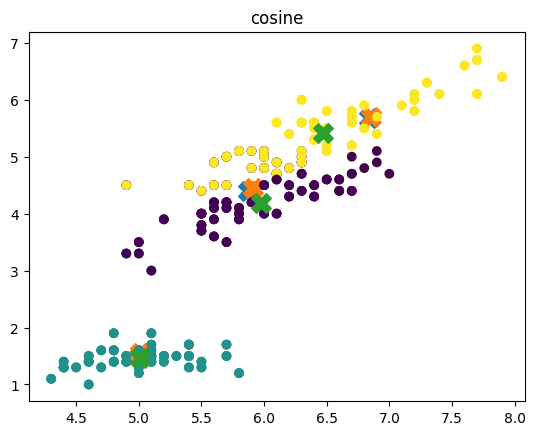

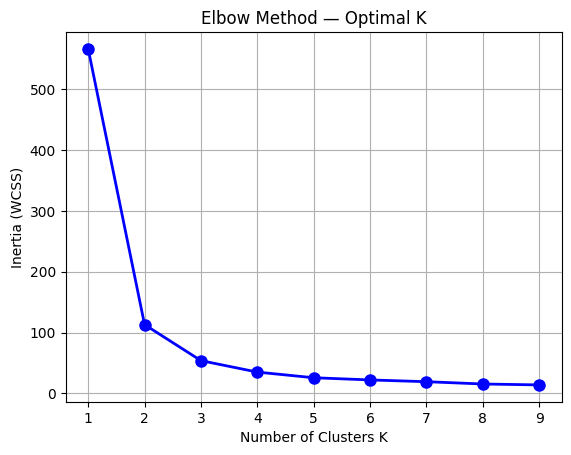

In [12]:
"""
Lab 6 Starter Code
K-Means From Scratch

This code provides a skeleton for implementing K-Means clustering.
Students are expected to complete the TODO sections.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_blobs

# ============================================================
# DATASET LOADERS
# ============================================================

def load_iris_dataset():
    """
    Load the Iris dataset.

    Tasks:
    - Select only two features: Sepal Length and Petal Length
      as specified in the lab (for 2D visualization).
    - Return the data as a NumPy array X of shape (150, 2).
    """
    data = load_iris()

    # TODO: select two features
    X = data.data[:, [0, 2]]  # Sepal Length (col 0) and Petal Length (col 2)

    return X


def generate_blobs(separable=True):
    """
    Generate synthetic clusters using sklearn.make_blobs.

    Parameters:
    - separable: if True, generate well-separated clusters
                 if False, generate overlapping clusters

    Tasks:
    - Create a dataset X with multiple clusters.
    - This allows observing K-Means behavior on different
      cluster distributions.
    """
    if separable:
        # TODO: generate well-separated blobs
        X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
    else:
        # TODO: generate overlapping blobs
        X, _ = make_blobs(n_samples=300, centers=3, cluster_std=3.5, random_state=42)

    return X


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def centroid_shift(old_centroids, new_centroids):
    """
    Compute how much centroids moved after an update.

    Parameters:
    - old_centroids: previous centroids
    - new_centroids: updated centroids

    Tasks:
    - Compute L2 norm of the difference between old and new centroids.
    - Used as a convergence criterion in K-Means.
    """
    # TODO implement actual computation
    # Example: np.linalg.norm(old_centroids - new_centroids)
    return np.linalg.norm(old_centroids - new_centroids)


# ============================================================
# KMEANS CLASS
# ============================================================

class MyKMeans:
    """
    K-Means clustering class.

    Tasks:
    - Implement K-Means algorithm from scratch.
    - Experiment with different distance metrics: Euclidean, Manhattan, Cosine.
    - Implement cluster assignment, centroid update, and convergence check.
    """

    def __init__(self, k=3, metric="euclidean", max_iter=100, random_state=42, tol=1e-4):
        """
        Initialize K-Means parameters.

        Parameters:
        - k: number of clusters
        - metric: distance metric to use
        - max_iter: maximum iterations before stopping
        """
        self.k = k
        self.metric = metric
        self.max_iter = max_iter
        self.random_state = random_state
        self.tol = tol
        self.centroids = None
        self.labels_ = None

    # --------------------------------------------------------
    # DISTANCE FUNCTION
    # --------------------------------------------------------

    def _distance(self, x1, x2):
        """
        Compute distance between two points.

        Tasks:
        - Implement three distance metrics:
          * Euclidean: circular clusters
          * Manhattan: diamond-shaped clusters
          * Cosine: measures angle between vectors
        - Hint for cosine: distance = 1 - (dot(x1,x2)/(||x1||*||x2||))
        """
        # TODO implement euclidean distance
        if self.metric == "euclidean":
            return np.sqrt(np.sum((x1 - x2) ** 2))

        # TODO implement manhattan distance
        elif self.metric == "manhattan":
            return np.sum(np.abs(x1 - x2))

        # TODO implement cosine distance
        elif self.metric == "cosine":
            dot = np.dot(x1, x2)
            norm = np.linalg.norm(x1) * np.linalg.norm(x2)
            if norm == 0:
                return 1.0
            return 1.0 - (dot / norm)

        else:
            raise ValueError(f"Unknown metric: {self.metric}")

    # --------------------------------------------------------

    def initialize_centroids(self, X):
        """
        Randomly select K points from dataset as initial centroids.

        Tasks:
        - Pick k random indices from X
        - Assign these points as initial centroids
        """
        # TODO
        indices = np.random.choice(X.shape[0], self.k, replace=False)
        return X[indices].copy()

    # --------------------------------------------------------

    def assign_clusters(self, X, centroids):
        """
        Assign each point to the nearest centroid.

        Tasks:
        - Compute distance from each point to every centroid
        - Assign label based on nearest centroid
        - Return array of cluster labels
        """
        # TODO
        labels = []
        for point in X:
            distances = [self._distance(point, c) for c in centroids]
            labels.append(np.argmin(distances))
        return np.array(labels)

    # --------------------------------------------------------

    def update_centroids(self, X, labels):
        """
        Update centroid positions based on cluster assignments.

        Tasks:
        - For each cluster, compute mean of points assigned to it
        - If a cluster has no points (empty), randomly reinitialize
          its centroid (safeguard)
        """
        centroids = []

        for i in range(self.k):
            # TODO: get points belonging to cluster i
            cluster_points = X[labels == i]

            if len(cluster_points) == 0:
                # SAFEGUARD: choose random point as centroid
                # TODO
                centroid = X[np.random.randint(0, X.shape[0])]
            else:
                # TODO: compute mean of cluster points
                centroid = cluster_points.mean(axis=0)

            centroids.append(centroid)

        return np.array(centroids)

    # --------------------------------------------------------

    def fit(self, X):
        """
        Fit the K-Means model to the data X.

        Algorithm:
        1. Initialize centroids
        2. Assign points to nearest centroid
        3. Update centroids
        4. Repeat until convergence (centroid movement < tol)
        or max iterations reached

        Tasks:
        - Implement K-Means training loop
        - Use centroid_shift to detect convergence
        """
        np.random.seed(self.random_state)
        centroids = self.initialize_centroids(X)

        for iteration in range(self.max_iter):
            labels = self.assign_clusters(X, centroids)
            new_centroids = self.update_centroids(X, labels)

            # TODO compute centroid movement
            shift = centroid_shift(centroids, new_centroids)

            if shift < self.tol:
                break

            centroids = new_centroids

        self.centroids = centroids
        self.labels_ = self.assign_clusters(X, centroids)

    # --------------------------------------------------------

    def predict(self, X):
        """
        Predict cluster labels for new data points.

        Tasks:
        - Compute distance from each point to centroids
        - Assign each point to nearest centroid
        """
        # TODO
        return self.assign_clusters(X, self.centroids)

    # --------------------------------------------------------
    # INERTIA
    # --------------------------------------------------------

    def compute_inertia(self, X, labels, centroids):
        """
        Compute Within-Cluster Sum of Squares (WCSS / Inertia).

        Tasks:
        - For each point, compute squared distance to its centroid
        - Sum all squared distances
        - Lower values indicate tighter clusters
        """
        # TODO
        total = 0.0
        for i, point in enumerate(X):
            centroid = centroids[labels[i]]
            total += np.sum((point - centroid) ** 2)
        return total


# ============================================================
# VISUALIZATION
# ============================================================

def plot_clusters(X, labels, centroids, title):
    """
    Scatter plot of clusters.

    Tasks:
    - Color points based on cluster labels
    - Plot centroids as 'X' markers
    """
    plt.scatter(X[:,0], X[:,1], c=labels)

    if centroids is not None:
        plt.scatter(
            centroids[:,0],
            centroids[:,1],
            marker='X',
            s=200
        )

    plt.title(title)


def plot_decision_boundaries(model, X):
    """
    Visualize clustering regions (decision boundaries).

    Tasks:
    - Create a mesh grid over the feature space
    - Predict cluster label for each grid point
    - Plot colored decision regions
    - Useful for comparing distance metrics
    """
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap='viridis', edgecolor='k')
    plt.scatter(model.centroids[:, 0], model.centroids[:, 1], marker='X', s=200, c='red')
    plt.title(f"Decision Boundaries ({model.metric})")
    plt.show()


# ============================================================
# ELBOW METHOD
# ============================================================

def plot_elbow_curve(X, k_values):
    """
    Elbow method to determine optimal K.

    Tasks:
    - Train K-Means for multiple K values
    - Compute inertia for each K
    - Plot inertia vs K
    - Observe the 'elbow' to estimate optimal clusters
    """
    inertias = []

    for k in k_values:
        model = MyKMeans(k=k)
        model.fit(X)
        labels = model.predict(X)

        # TODO compute inertia
        inertia = model.compute_inertia(X, labels, model.centroids)
        inertias.append(inertia)

    # TODO: plot inertia vs k
    plt.figure()
    plt.plot(list(k_values), inertias, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Number of Clusters K')
    plt.ylabel('Inertia (WCSS)')
    plt.title('Elbow Method — Optimal K')
    plt.xticks(list(k_values))
    plt.grid(True)
    plt.show()


# ============================================================
# MAIN DEMO
# ============================================================

def main():
    """
    Main demonstration.

    Tasks:
    - Load Iris dataset
    - Run K-Means with different metrics: Euclidean, Manhattan, Cosine
    - Visualize resulting clusters
    - Run Elbow method to determine optimal K
    """
    X = load_iris_dataset()
    metrics = ["euclidean", "manhattan", "cosine"]

    for metric in metrics:
        model = MyKMeans(k=3, metric=metric)
        model.fit(X)
        labels = model.predict(X)
        plot_clusters(X, labels, model.centroids, metric)

    plt.show()

    # Elbow Method
    plot_elbow_curve(X, range(1,10))


if __name__ == "__main__":
    main()

---
## Part A: Distance Function
Testing Euclidean, Manhattan, and Cosine distance implementations.

In [13]:
# Quick sanity checks for distance metrics
m_euc = MyKMeans(metric="euclidean")
m_man = MyKMeans(metric="manhattan")
m_cos = MyKMeans(metric="cosine")

x1, x2 = np.array([0, 0]), np.array([3, 4])

print("Euclidean distance (0,0) -> (3,4):", m_euc._distance(x1, x2))  # expected 5.0
print("Manhattan distance (0,0) -> (3,4):", m_man._distance(x1, x2))  # expected 7
print("Cosine distance   (1,0) -> (0,1):",
      m_cos._distance(np.array([1, 0]), np.array([0, 1])))             # expected 1.0

Euclidean distance (0,0) -> (3,4): 5.0
Manhattan distance (0,0) -> (3,4): 7
Cosine distance   (1,0) -> (0,1): 1.0


---
## Part B & C: Cluster Assignment and Centroid Update

In [14]:
simple_dataset = np.array([
    [1.0, 1.0], [1.2, 1.1], [0.8, 0.9],
    [5.0, 5.0], [5.1, 4.9], [4.9, 5.2]
])

model = MyKMeans(k=2)
centroids_init = np.array([[1, 1], [5, 5]], dtype=float)

labels = model.assign_clusters(simple_dataset, centroids_init)
print("Cluster labels:", labels)   # expected [0 0 0 1 1 1]

new_centroids = model.update_centroids(simple_dataset, labels)
print("Updated centroids:\n", new_centroids)

Cluster labels: [0 0 0 1 1 1]
Updated centroids:
 [[1.         1.        ]
 [5.         5.03333333]]


---
## Part D: Full K-Means fit + predict

Iris dataset shape: (150, 2)


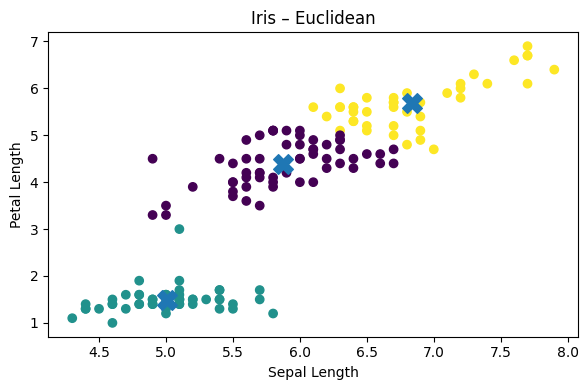

In [15]:
X_iris = load_iris_dataset()
print("Iris dataset shape:", X_iris.shape)  # (150, 2)

model_iris = MyKMeans(k=3, metric="euclidean")
model_iris.fit(X_iris)
labels_iris = model_iris.predict(X_iris)

plt.figure(figsize=(6, 4))
plot_clusters(X_iris, labels_iris, model_iris.centroids, "Iris – Euclidean")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.tight_layout()
plt.show()

---
## Part E: Decision Boundary Visualization
Running K-Means with all three distance metrics on the Iris dataset.

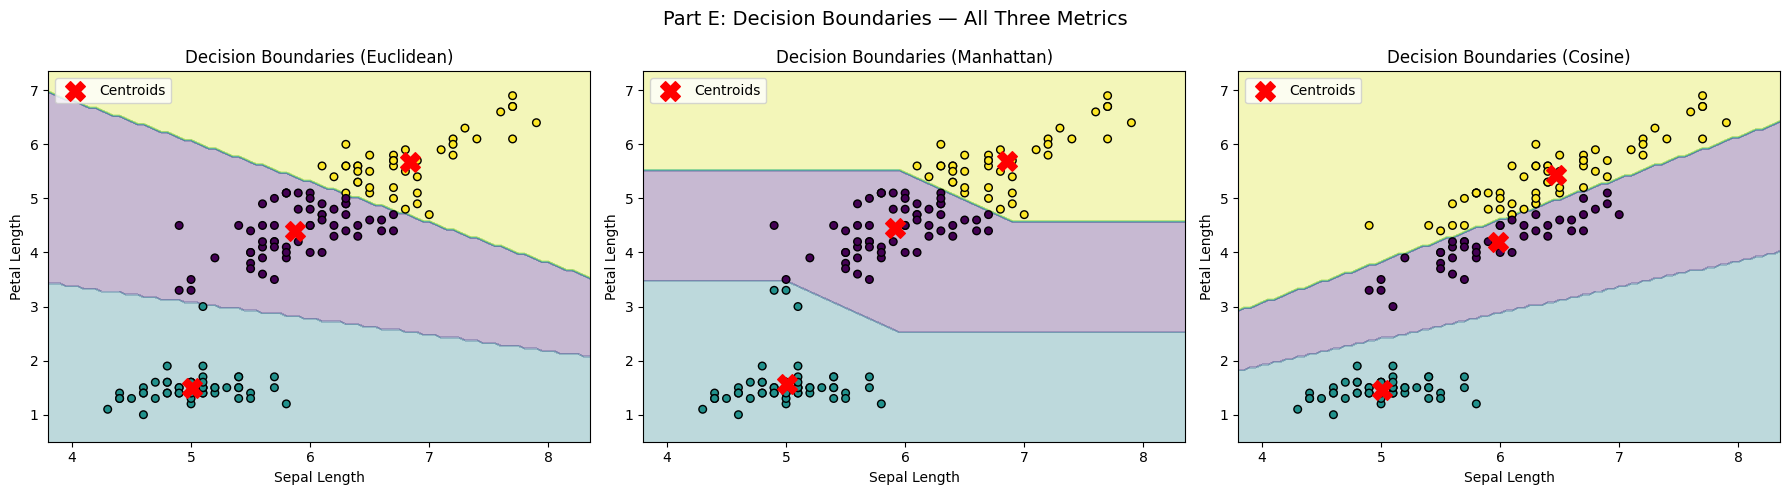

In [16]:
metrics = ["euclidean", "manhattan", "cosine"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    plt.sca(ax)
    model_m = MyKMeans(k=3, metric=metric)
    model_m.fit(X_iris)

    x_min, x_max = X_iris[:, 0].min() - 0.5, X_iris[:, 0].max() + 0.5
    y_min, y_max = X_iris[:, 1].min() - 0.5, X_iris[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_m.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_iris[:, 0], X_iris[:, 1],
               c=model_m.labels_, cmap='viridis', edgecolor='k', s=30)
    ax.scatter(model_m.centroids[:, 0], model_m.centroids[:, 1],
               marker='X', s=200, c='red', label='Centroids')
    ax.set_title(f"Decision Boundaries ({metric.capitalize()})")
    ax.set_xlabel("Sepal Length")
    ax.set_ylabel("Petal Length")
    ax.legend()

plt.suptitle("Part E: Decision Boundaries — All Three Metrics", fontsize=14)
plt.tight_layout()
plt.show()

---
## Part F: Experimental Comparison — Iris vs Synthetic Datasets

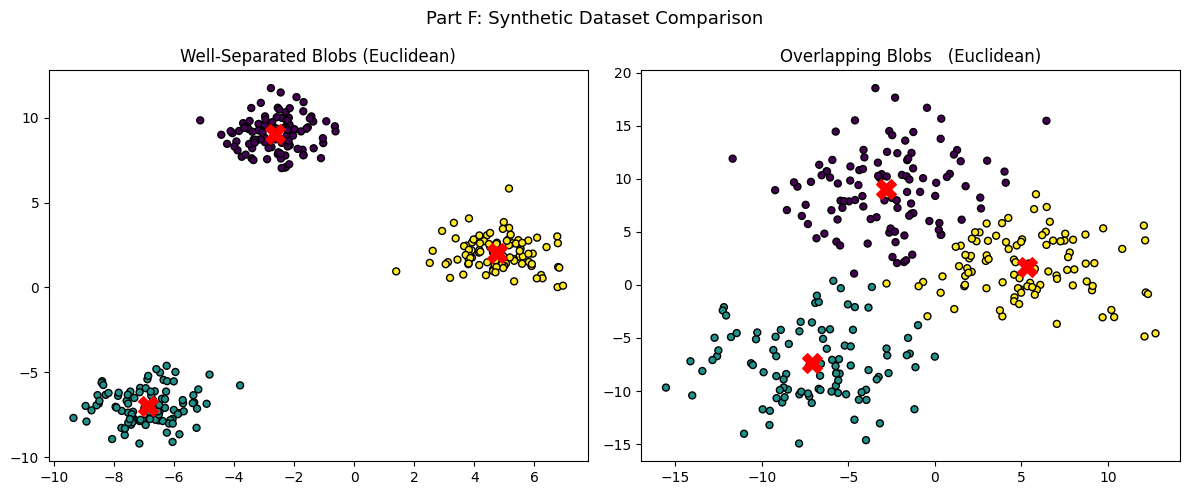

In [17]:
X_sep  = generate_blobs(separable=True)
X_over = generate_blobs(separable=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (X_data, title) in zip(axes, [
    (X_sep,  "Well-Separated Blobs (Euclidean)"),
    (X_over, "Overlapping Blobs   (Euclidean)"),
]):
    model_b = MyKMeans(k=3, metric="euclidean")
    model_b.fit(X_data)
    lb = model_b.predict(X_data)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=lb, cmap='viridis', edgecolor='k', s=25)
    ax.scatter(model_b.centroids[:, 0], model_b.centroids[:, 1],
               marker='X', s=200, c='red')
    ax.set_title(title)

plt.suptitle("Part F: Synthetic Dataset Comparison", fontsize=13)
plt.tight_layout()
plt.show()

---
## Inertia (WCSS) and Elbow Method

In [18]:
# Inertia for Iris with k=3, euclidean
inertia_iris = model_iris.compute_inertia(X_iris, labels_iris, model_iris.centroids)
print(f"Inertia (Iris, k=3, Euclidean): {inertia_iris:.4f}")

Inertia (Iris, k=3, Euclidean): 53.8100


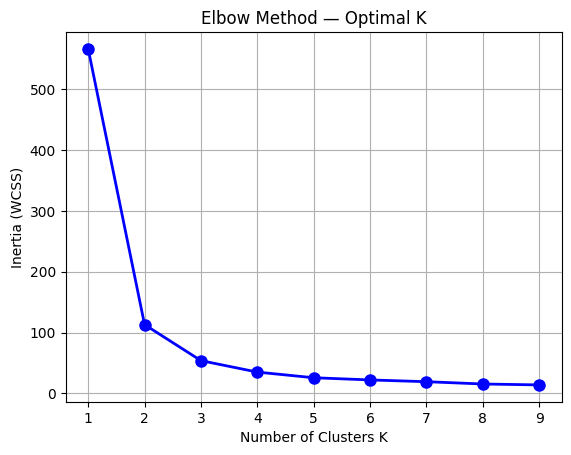

In [19]:
# Part G: Elbow Method on Iris dataset
plot_elbow_curve(X_iris, range(1, 10))

---
## Test Suite: `lab6_test_kmeans.py`
Run all unit tests directly in the notebook using `pytest` via `ipytest`.

> **To run tests from terminal:** `pytest -v lab6_test_kmeans.py`

In [20]:
# Install ipytest if not already available
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "ipytest", "-q"])

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'ipytest', '-q'], returncode=0)

In [21]:
import ipytest
ipytest.autoconfig()

In [22]:
%%ipytest -v

import numpy as np
import pytest 

# ==========================================================
# HELPER DATASETS
# ==========================================================

@pytest.fixture
def simple_dataset():
    """
    Small dataset with two obvious clusters.
    """
    X = np.array([
        [1.0, 1.0],
        [1.2, 1.1],
        [0.8, 0.9],
        [5.0, 5.0],
        [5.1, 4.9],
        [4.9, 5.2]
    ])
    return X


# ==========================================================
# DATASET LOADING
# ==========================================================

def test_load_iris_dataset():

    X = load_iris_dataset()

    assert isinstance(X, np.ndarray)
    assert X.shape[1] == 2
    assert X.shape[0] == 150


def test_generate_blobs():

    X = generate_blobs(separable=True)

    assert isinstance(X, np.ndarray)
    assert X.shape[1] == 2


# ==========================================================
# DISTANCE METRICS
# ==========================================================

def test_distance_euclidean():

    model = MyKMeans(metric="euclidean")

    x1 = np.array([0,0])
    x2 = np.array([3,4])

    d = model._distance(x1,x2)

    assert pytest.approx(d, rel=1e-3) == 5.0


def test_distance_manhattan():

    model = MyKMeans(metric="manhattan")

    x1 = np.array([0,0])
    x2 = np.array([3,4])

    d = model._distance(x1,x2)

    assert d == 7


def test_distance_cosine():

    model = MyKMeans(metric="cosine")

    x1 = np.array([1,0])
    x2 = np.array([0,1])

    d = model._distance(x1,x2)

    assert pytest.approx(d, rel=1e-3) == 1.0


# ==========================================================
# INITIALIZATION
# ==========================================================

def test_initialize_centroids(simple_dataset):

    model = MyKMeans(k=2)

    centroids = model.initialize_centroids(simple_dataset)

    assert centroids.shape == (2,2)


# ==========================================================
# CLUSTER ASSIGNMENT
# ==========================================================

def test_assign_clusters(simple_dataset):

    model = MyKMeans(k=2)

    centroids = np.array([
        [1,1],
        [5,5]
    ])

    labels = model.assign_clusters(simple_dataset, centroids)

    assert labels.shape[0] == simple_dataset.shape[0]
    assert set(labels) <= {0,1}


# ==========================================================
# CENTROID UPDATE
# ==========================================================

def test_update_centroids(simple_dataset):

    model = MyKMeans(k=2)

    labels = np.array([0,0,0,1,1,1])

    centroids = model.update_centroids(simple_dataset, labels)

    assert centroids.shape == (2,2)


# ==========================================================
# CENTROID SHIFT
# ==========================================================

def test_centroid_shift():

    old = np.array([
        [1,1],
        [5,5]
    ])

    new = np.array([
        [1.1,1],
        [5,5.1]
    ])

    shift = centroid_shift(old,new)

    assert shift > 0


# ==========================================================
# FIT METHOD
# ==========================================================

def test_fit_runs(simple_dataset):

    model = MyKMeans(k=2)

    model.fit(simple_dataset)

    assert model.centroids is not None


# ==========================================================
# PREDICT
# ==========================================================

def test_predict(simple_dataset):

    model = MyKMeans(k=2)

    model.fit(simple_dataset)

    labels = model.predict(simple_dataset)

    assert len(labels) == simple_dataset.shape[0]


# ==========================================================
# INERTIA
# ==========================================================

def test_compute_inertia(simple_dataset):

    model = MyKMeans(k=2)

    model.fit(simple_dataset)

    labels = model.predict(simple_dataset)

    inertia = model.compute_inertia(
        simple_dataset,
        labels,
        model.centroids
    )

    assert inertia >= 0


# ==========================================================
# EMPTY CLUSTER SAFEGUARD
# ==========================================================

def test_empty_cluster_handling():

    X = np.array([
        [1,1],
        [1.1,1],
        [10,10]
    ])

    model = MyKMeans(k=3)

    model.fit(X)

    assert model.centroids.shape == (3,2)

======================================= test session starts ========================================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: anyio-4.12.1, langsmith-0.7.18, typeguard-4.5.1
collected 13 items

t_1cdfce48c32a4d98ad899a2645a813cb.py .............                                          [100%]

======================================== 13 passed in 0.06s ========================================
